C:\Users\ASUS\AppData\Local\Temp\ipykernel_7004\335142250.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Sales_Millions", y="Title", ax=axes[0, 0], palette="viridis")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_7004\335142250.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_efficiency, x="Sales_Per_Volume", y="Title", ax=axes[1, 1], palette="magma")


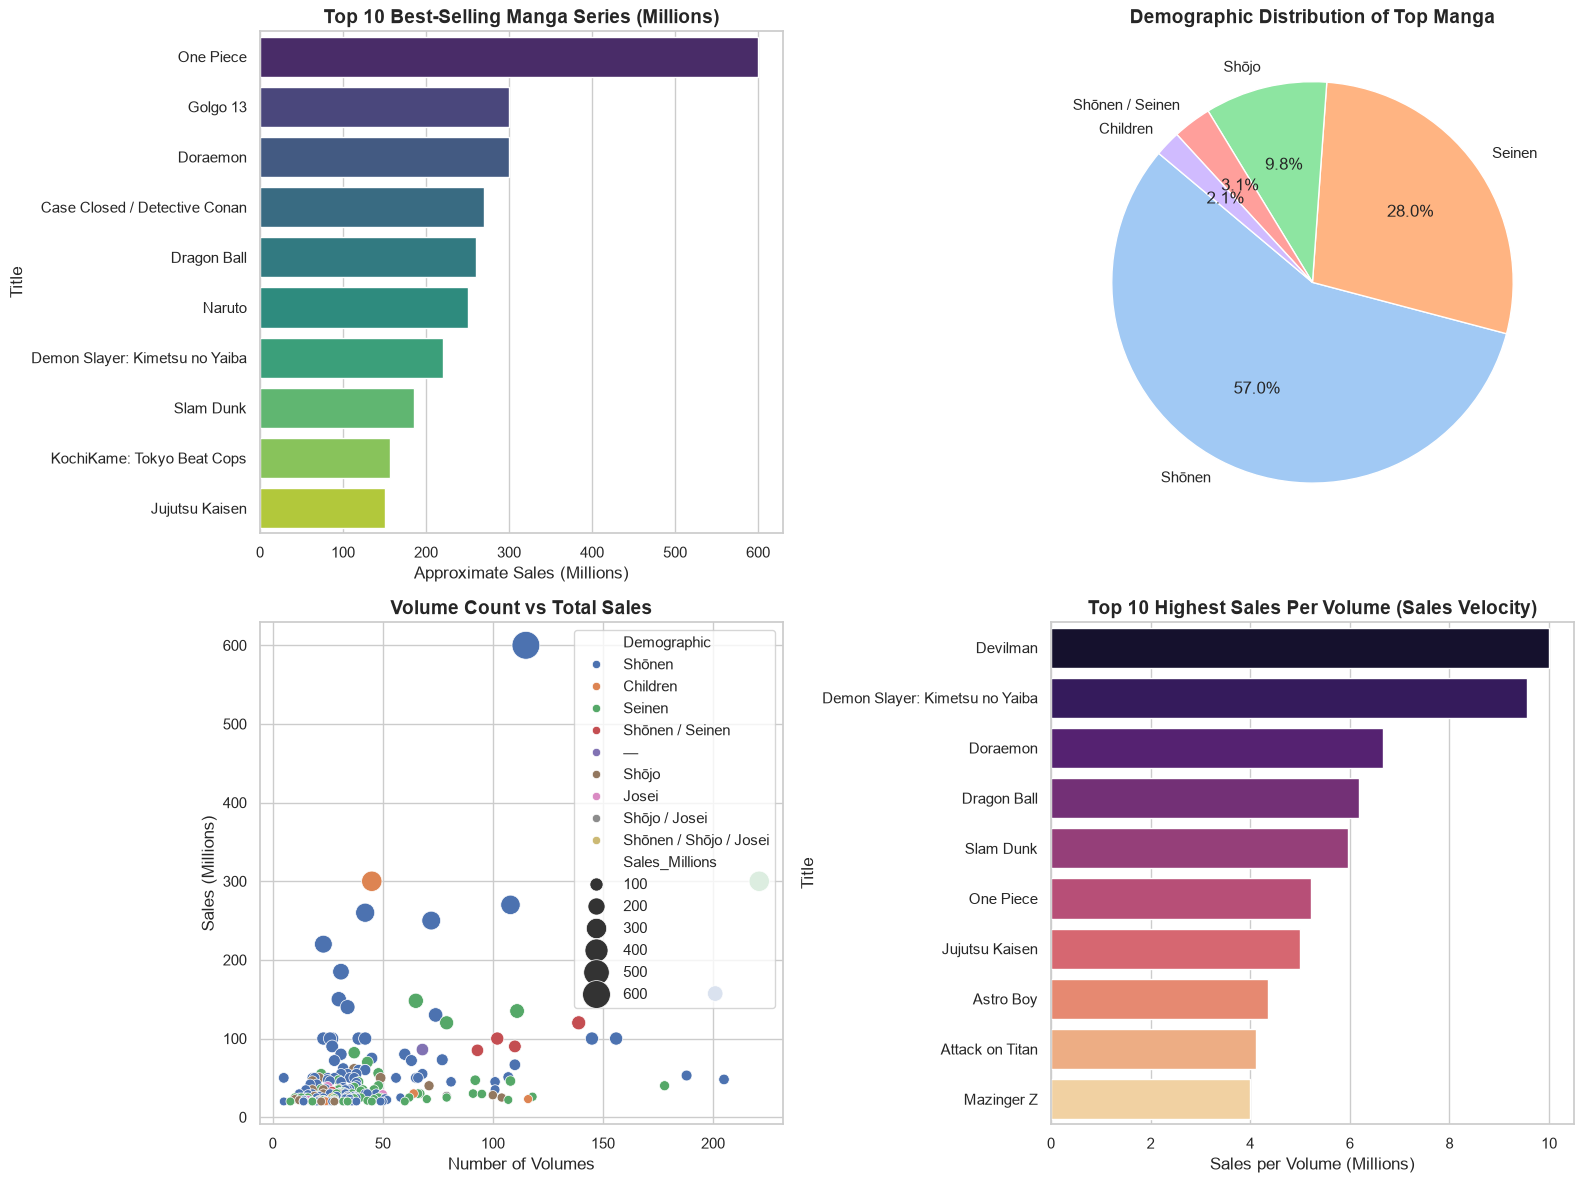

In [8]:
import re
import io
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

# --- STEP 1: WEB SCRAPING ---
URL = "https://en.wikipedia.org/wiki/List_of_best-selling_manga"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

response = requests.get(URL, headers=headers)
soup = BeautifulSoup(response.content, "html.parser")

# Find wikitables on the page
tables = soup.find_all("table", {"class": "wikitable"})

manga_list = []

for table in tables:
    rows = table.find_all("tr")
    for row in rows[1:]:  # Skip header
        cols = row.find_all(["td", "th"])
        if len(cols) >= 6:
            title = cols[0].text.strip()
            author = cols[1].text.strip()
            publisher = cols[2].text.strip()
            demographic = cols[3].text.strip()
            volumes = cols[4].text.strip()
            sales = cols[-1].text.strip()
            
            manga_list.append({
                "Title": title,
                "Author": author,
                "Publisher": publisher,
                "Demographic": demographic,
                "Volumes": volumes,
                "Sales_Raw": sales
            })

df = pd.DataFrame(manga_list)

# --- STEP 2: DATA CLEANING ---
def clean_number(val):
    # Extract first sequence of digits
    val = re.sub(r"\[.*?\]|†|‡|,", "", val)
    match = re.search(r"(\d+(\.\d+)?)", val)
    return float(match.group(1)) if match else None

df["Sales_Millions"] = df["Sales_Raw"].apply(clean_number)
df["Volumes_Clean"] = df["Volumes"].apply(clean_number)

# Filter valid entries & drop missing data
df_clean = df.dropna(subset=["Sales_Millions", "Volumes_Clean"]).copy()

# Derived Metric: Sales Per Volume
df_clean["Sales_Per_Volume"] = df_clean["Sales_Millions"] / df_clean["Volumes_Clean"]

# --- STEP 3: VISUALIZATIONS ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Top 10 Best-Selling Manga
top10 = df_clean.sort_values(by="Sales_Millions", ascending=False).head(10)
sns.barplot(data=top10, x="Sales_Millions", y="Title", ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Top 10 Best-Selling Manga Series (Millions)", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Approximate Sales (Millions)")

# Chart 2: Demographic Distribution
demo_counts = df_clean["Demographic"].value_counts().head(5)
axes[0, 1].pie(demo_counts, labels=demo_counts.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
axes[0, 1].set_title("Demographic Distribution of Top Manga", fontsize=14, fontweight="bold")

# Chart 3: Sales vs Volume Count (Scatter Plot)
sns.scatterplot(data=df_clean, x="Volumes_Clean", y="Sales_Millions", hue="Demographic", size="Sales_Millions", sizes=(40, 400), ax=axes[1, 0])
axes[1, 0].set_title("Volume Count vs Total Sales", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Number of Volumes")
axes[1, 0].set_ylabel("Sales (Millions)")

# Chart 4: Efficiency (Sales Per Volume - Top 10)
top_efficiency = df_clean.sort_values(by="Sales_Per_Volume", ascending=False).head(10)
sns.barplot(data=top_efficiency, x="Sales_Per_Volume", y="Title", ax=axes[1, 1], palette="magma")
axes[1, 1].set_title("Top 10 Highest Sales Per Volume (Sales Velocity)", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Sales per Volume (Millions)")

plt.tight_layout()
plt.show()